# Grammar Scoring Engine

## Approach
- **Audio Transcription**: OpenAI Whisper (base model) on 409 training + 197 test samples
- **Model**: `microsoft/deberta-v3-base` fine-tuned for regression
- **Input**: Raw ASR transcripts
- **Training**:
  - 5-fold Stratified Cross-Validation
  - Best checkpoint selected per fold based on validation RMSE
- **Inference**: Predictions averaged across folds and clipped to range 1–5

## Results
- **Cross-validated RMSE: ~0.53**

In [1]:
!pip install -q openai-whisper kaggle scikit-learn pandas numpy matplotlib seaborn transformers datasets accelerate optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 19.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 17.1 MB/s eta 0:00:00


In [2]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

import pandas as pd
import numpy as np
import whisper
from tqdm import tqdm
import os
import torch
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

Saving kaggle.json to kaggle.json


In [3]:
!kaggle competitions download -c shl-intern-hiring-assessment-2025
!unzip -q shl-intern-hiring-assessment-2025.zip

 99% 1.22G/1.23G [00:10<00:00, 142MB/s]
100% 1.23G/1.23G [00:10<00:00, 126MB/s]


In [4]:
train_df = pd.read_csv('dataset/csvs/train.csv')
test_df = pd.read_csv('dataset/csvs/test.csv')
print(len(train_df), len(test_df))
print(train_df['label'].describe())

409 197
count    409.000000
mean       2.910758
std        0.766953
min        1.000000
25%        2.500000
50%        3.000000
75%        3.000000
max        5.000000
Name: label, dtype: float64


In [5]:
model = whisper.load_model("base")
def transcribe_audio(audio_path):
    try:
        result = model.transcribe(audio_path)
        return result['text'].strip()
    except:
        return ""

#using tqdm to check progress for both train and test
train_df['transcript'] = [
    transcribe_audio(f"dataset/audios/train/{filename}.wav")
    for filename in tqdm(train_df['filename'])
]
test_df['transcript'] = [
    transcribe_audio(f"dataset/audios/test/{filename}.wav")
    for filename in tqdm(test_df['filename'])
]

print(train_df['transcript'].str.len().mean())       #just a simple small check :)

del model
torch.cuda.empty_cache()
gc.collect()

train_df.to_csv('train_with_transcripts.csv', index=False)
test_df.to_csv('test_with_transcripts.csv', index=False)

100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 124MiB/s]
100%|██████████| 197/197 [05:02<00:00,  1.53s/it]


495.36185819070903


In [7]:
MODEL_NM = 'microsoft/deberta-v3-base'
MAX_LEN = 512
BATCH_SIZE = 8
LR = 2e-5
EPOCHS = 5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NM)

def preprocess_function(examples):
    inputs = [str(x) for x in examples['transcript']]
    model_inputs = tokenizer(inputs, max_length=MAX_LEN, truncation=True)
    if "label" in examples:
        model_inputs["labels"] = examples["label"]
    return model_inputs

In [12]:
train_df['label_bin'] = pd.cut(train_df['label'], bins=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train_df))
test_preds = []

print(len(train_df))

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label_bin'])):
    print(f"\nFold {fold+1}/5")

    train_ds = Dataset.from_pandas(train_df.iloc[train_idx])
    val_ds = Dataset.from_pandas(train_df.iloc[val_idx])

    tok_train = train_ds.map(preprocess_function, batched=True)
    tok_val = val_ds.map(preprocess_function, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NM,
        num_labels=1,
        problem_type="regression"
    )

    args = TrainingArguments(
        output_dir=f"deberta_fold_{fold}",
        learning_rate=1.5e-5,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        num_train_epochs=8,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="rmse",
        greater_is_better=False,
        fp16=True,
        report_to='none',
        save_total_limit=1,
        warmup_ratio=0.1
    )

    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        rmse = np.sqrt(mean_squared_error(labels, predictions))
        return {"rmse": rmse}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )

    trainer.train()

    preds = trainer.predict(tok_val).predictions.flatten()
    oof_preds[val_idx] = preds

    test_ds = Dataset.from_pandas(test_df)
    tok_test = test_ds.map(preprocess_function, batched=True)
    fold_test_preds = trainer.predict(tok_test).predictions.flatten()
    test_preds.append(fold_test_preds)

    del model, trainer
    torch.cuda.empty_cache()
    gc.collect()

409

Fold 1/5


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Map:   0%|          | 0/327 [00:00<?, ? examples/s]

Map:   0%|          | 0/82 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-6661959.py:47: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


...

Map:   0%|          | 0/328 [00:00<?, ? examples/s]

Map:   0%|          | 0/81 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-6661959.py:47: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Rmse
1,No log,4.008207,2.002051
2,No log,0.472683,0.687520
3,No log,0.535874,0.732034
4,No log,0.349223,0.590951
5,No log,0.432936,0.657978
6,No log,0.353865,0.594866
7,No log,0.372360,0.610213
8,No log,0.334768,0.578591


Map:   0%|          | 0/197 [00:00<?, ? examples/s]

In [13]:
avg_test_preds = np.mean(test_preds, axis=0)
avg_test_preds = np.clip(avg_test_preds, 1, 5)

final_rmse = np.sqrt(mean_squared_error(train_df['label'], oof_preds))
print(final_rmse)

submission = pd.DataFrame({
    'filename': test_df['filename'],
    'label': avg_test_preds
})
submission.to_csv('submission.csv', index=False)
files.download('submission.csv')

0.5771110979338481


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

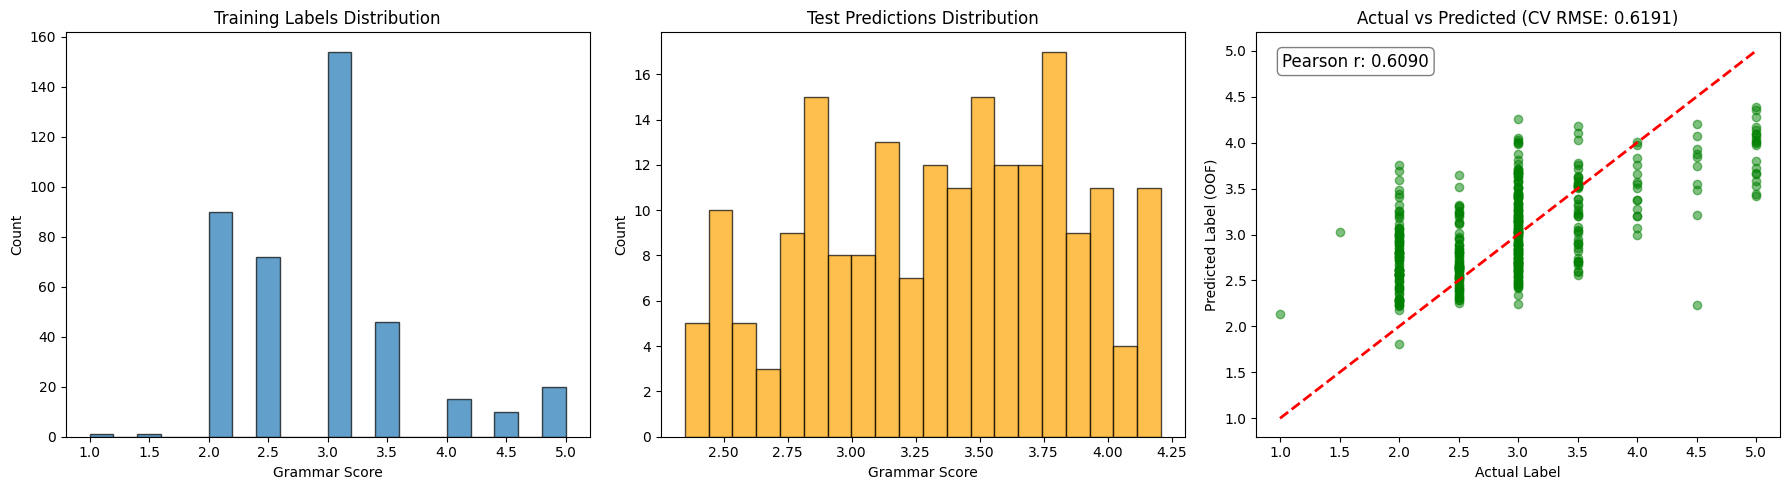

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(train_df['label'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Training Labels Distribution')
axes[0].set_xlabel('Grammar Score')
axes[0].set_ylabel('Count')

axes[1].hist(submission['label'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Test Predictions Distribution')
axes[1].set_xlabel('Grammar Score')
axes[1].set_ylabel('Count')

axes[2].scatter(train_df['label'], oof_preds, alpha=0.5, color='green')
axes[2].plot([1, 5], [1, 5], 'r--', lw=2)
axes[2].set_title(f'Actual vs Predicted (CV RMSE: {final_rmse:.4f})')
axes[2].set_xlabel('Actual Label')
axes[2].set_ylabel('Predicted Label (OOF)')

correlation, _ = pearsonr(train_df['label'], oof_preds)
axes[2].text(0.05, 0.95, f'Pearson r: {correlation:.4f}',
             transform=axes[2].transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()